# Exercises 2. Uninformed Search Algorithms

## 1. Generate a random tree

Write a function to generate a random tree (for use with GraphViz) with the following parameters: maximum depth and maximum branching coefficient, minimum edge weight, and maximum edge weight.

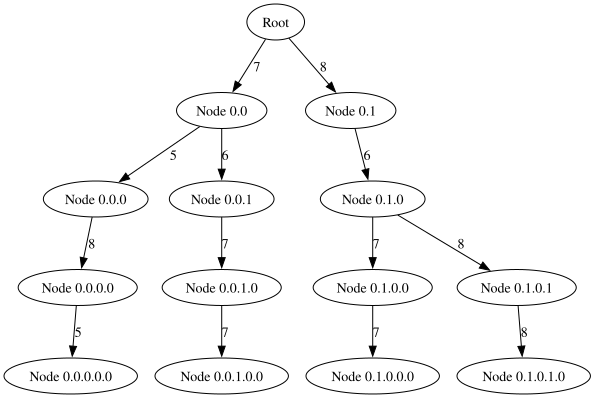

In [38]:
# Generate a random tree
#Write a function to generate a random tree (for use with GraphViz) with the following parameters: 
# maximum depth and maximum branching coefficient, minimum edge weight, and maximum edge weight.
from graphviz import Digraph
import random

def generate_random_tree(max_depth, max_branching, min_edge_weight, max_edge_weight):
    tree = Digraph()
    tree.node('0', 'Root')
    
    def add_children(node_id, depth):
        if depth < max_depth:
            num_children = random.randint(1, max_branching)
            for i in range(num_children):
                child_id = f"{node_id}.{i}"
                edge_weight = random.randint(min_edge_weight, max_edge_weight)
                tree.node(child_id, f"Node {child_id}")
                tree.edge(node_id, child_id, label=str(edge_weight))
                add_children(child_id, depth + 1)
    
    add_children('0', 0)
    return tree
# Generate a random tree with specified parameters and visualize it using GraphViz.
random_tree = generate_random_tree(random.randint(2, 5), random.randint(2, 4), random.randint(1, 5), random.randint(6, 10))
random_tree

## 2. Generate a GraphViz .dot file
- What is a GraphViz .dot file?

A .dot file is a plain-text document written in the DOT language. It describes a graph by listing its nodes and the edges (connections) between them. Software like Graphviz then reads this text file and renders it into an image (like a PNG, SVG, or PDF).

    - Directed vs. Undirected: Use digraph for directed graphs (arrows) and graph for undirected ones (lines).
    - Simple Syntax: A basic connection looks like A -> B;.
    - Attributes: You can customize colors, shapes, and labels by adding brackets, such as Node1 [label="Root", color="blue"];.


- Write a function to generate a GraphViz .dot file from the above tree.

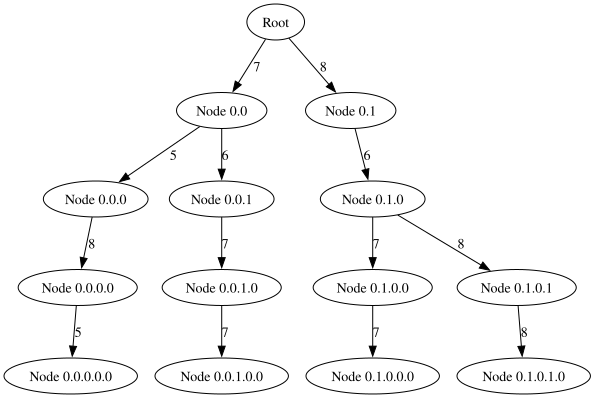

In [39]:
# - Write a function to generate a GraphViz .dot file from the above tree.
from graphviz import Source

dot = random_tree.source
with open('random_tree.dot', 'w') as f:
    f.write(dot)
# - Write a function to visualize the tree using GraphViz.
Source.from_file('random_tree.dot')

## 3. Render trees

Write a function to render the above tree using GraphViz.

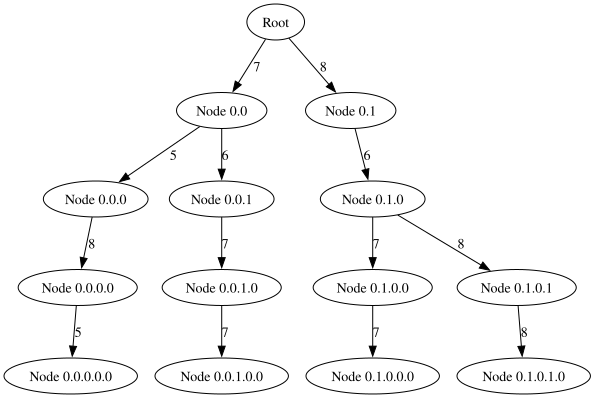

In [40]:
# Write a function to render the above tree using GraphViz.
random_tree.render('random_tree', format='png', cleanup=True)
random_tree

## 4. Applying the UCS algorithm

### 4.1. Search for a goal state

Write a function to find a specified goal state on the state tree using the UCS algorithm. When a state is visited, print the label of that state.

In [41]:
# Write a function to find a specified goal state on the state tree using the UCS algorithm. 
# When a state is visited, print the label of that state.

import heapq

def ucs(tree, start, goal):
    visited = set()
    # Priority Queue stores (cumulative_cost, current_node_id)
    queue = [(0, start)]  
    
    # Parse edges from the DOT source string since graphviz.Digraph doesn't have get_edges()
    all_edges = []
    for line in tree.source.split('\n'):
        line = line.strip()
        if '->' in line:
            parts = line.split(' -> ')
            if len(parts) == 2:
                source = parts[0].strip().strip('"')
                dest_part = parts[1].strip()
                if '[' in dest_part:
                    dest, attr = dest_part.split(' [', 1)
                    dest = dest.strip().strip('"')
                    attr = attr.rstrip(']')
                    if 'label=' in attr:
                        label = attr.split('label=')[1].strip().strip('"')
                        edge_weight = int(label)
                    else:
                        edge_weight = 1
                else:
                    dest = dest_part.strip().strip('"')
                    edge_weight = 1
                all_edges.append((source, dest, edge_weight))

    while queue:
        cost, node_id = heapq.heappop(queue)
        
        if node_id in visited:
            continue
        
        print(f"Visiting node: {node_id}")
        visited.add(node_id)
        
        if node_id == goal:
            print(f"Goal {goal} found with cost: {cost}")
            return cost
        
        # Iterate through parsed edges
        for source, child_id, edge_weight in all_edges:
            if source == node_id:
                if child_id not in visited:
                    heapq.heappush(queue, (cost + edge_weight, child_id))
    
    print(f"Goal {goal} not found.")
    return None

# Example usage:
# Assuming the tree has nodes like '0', '0.0', '0.1', etc.
ucs(random_tree, '0', '0.0.0')  # Replace '0.0.0' with an actual goal node ID from your tree

Visiting node: 0
Visiting node: 0.0
Visiting node: 0.1
Visiting node: 0.0.0
Goal 0.0.0 found with cost: 12


12

### 4.2. Using animation

Write a function that illustrates a step-by-step process of searching for a specified target state using animation. Allow for adjustment of animation speed.

In [42]:
# Write a function that illustrates a step-by-step process of searching for a specified target state using animation. 
# Allow for adjustment of animation speed.
# Highlight color green the visited nodes and edges during the search process .
import time
import imageio
import os

def animate_ucs(tree, start, goal, animation_speed=1.0):
    visited = set()
    queue = [(0, start)]
    all_edges = []
    
    for line in tree.source.split('\n'):
        line = line.strip()
        if '->' in line:
            parts = line.split(' -> ')
            if len(parts) == 2:
                source = parts[0].strip().strip('"')
                dest_part = parts[1].strip()
                if '[' in dest_part:
                    dest, attr = dest_part.split(' [', 1)
                    dest = dest.strip().strip('"')
                    attr = attr.rstrip(']')
                    if 'label=' in attr:
                        label = attr.split('label=')[1].strip().strip('"')
                        edge_weight = int(label)
                    else:
                        edge_weight = 1
                else:
                    dest = dest_part.strip().strip('"')
                    edge_weight = 1
                all_edges.append((source, dest, edge_weight))
    
    # Parse nodes from the DOT source
    all_nodes = []
    for line in tree.source.split('\n'):
        line = line.strip()
        if '[' in line and ']' in line and '->' not in line:
            parts = line.split(' [', 1)
            node_id = parts[0].strip().strip('"')
            attr = parts[1].rstrip(']')
            label = attr.split('label=')[1].strip().strip('"') if 'label=' in attr else node_id
            all_nodes.append((node_id, {'label': label}))
    
    images = []
    
    while queue:
        cost, node_id = heapq.heappop(queue)
        
        if node_id in visited:
            continue
        
        print(f"Visiting node: {node_id}")
        visited.add(node_id)
        
        # Highlight the current node and edges
        temp_tree = Digraph()
        for node_id_parsed, node_attr in all_nodes:
            color = 'green' if node_id_parsed in visited else 'black'
            temp_tree.node(node_id_parsed, node_attr['label'], color=color)
        for edge in all_edges:
            color = 'green' if edge[0] in visited and edge[1] in visited else 'black'
            temp_tree.edge(edge[0], edge[1], label=str(edge[2]), color=color)
        
        # Save the current state as an image
        temp_tree.render('temp_tree', format='png', cleanup=True)
        images.append(imageio.imread('temp_tree.png'))
        
        time.sleep(animation_speed)  # Adjust animation speed
        
        if node_id == goal:
            print(f"Goal {goal} found with cost: {cost}")
            break
        
        for source, child_id, edge_weight in all_edges:
            if source == node_id and child_id not in visited:
                heapq.heappush(queue, (cost + edge_weight, child_id))
    
    # Create an animated GIF
    imageio.mimsave('ucs_animation.gif', images, duration=animation_speed)
    os.remove('temp_tree.png')  # Clean up temporary image file

animate_ucs(random_tree, '0', '0.0.0.1.0.1', animation_speed=1.0)  # Replace '0.0.0' with an actual goal node ID from your tree

Visiting node: 0


/tmp/ipykernel_65902/1129692720.py:67: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  images.append(imageio.imread('temp_tree.png'))


Visiting node: 0.0


/tmp/ipykernel_65902/1129692720.py:67: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  images.append(imageio.imread('temp_tree.png'))


Visiting node: 0.1


...

/tmp/ipykernel_65902/1129692720.py:67: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  images.append(imageio.imread('temp_tree.png'))


Visiting node: 0.1.0.0.0


/tmp/ipykernel_65902/1129692720.py:67: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  images.append(imageio.imread('temp_tree.png'))


Visiting node: 0.1.0.1.0


/tmp/ipykernel_65902/1129692720.py:67: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  images.append(imageio.imread('temp_tree.png'))


### 4.3. Export animation

Export the animation illustrating the search process as a dynamic GIF file.

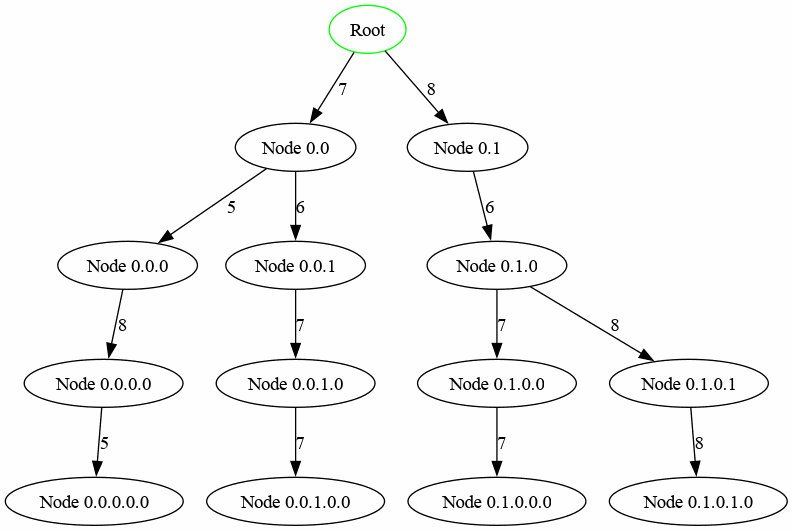

In [43]:
#Only Export the animation illustrating the search process as a dynamic GIF file.
#loop through the generated images and create a GIF using imageio
from IPython.display import Image
Image(filename='ucs_animation.gif')